# 05 Review Pack

This notebook is the final presentation layer: summarize the evaluation population, focus on flagged bonds, and explain why each case would or would not need analyst review.

The purpose of this step is to turn the pricing output into something operational. A reviewer should be able to look at a short list of names, understand why they were escalated, and decide where deeper investigation is worth the time.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
from IPython.display import Image, display

from src.review_pack import build_flagged_summary, build_summary_metrics, load_evaluation_table

In [3]:
evaluation_table = load_evaluation_table(PROJECT_ROOT / "outputs" / "daily_eval_table.csv")
summary = build_summary_metrics(evaluation_table)
summary

,evaluation_date,bond_count,review_count,high_review_count,avg_abs_spread_residual_bps,avg_abs_price_residual,max_abs_spread_residual_bps,max_abs_price_residual
0,2026-04-06,8,8,5,23.750614,1.706622,41.888878,5.063431


In [4]:
flagged = build_flagged_summary(evaluation_table)
flagged

,bond_id,issuer,dirty_price,fair_model_dirty_price,price_residual,spread_to_curve,fair_spread,spread_residual_bps,comp_count,review_flag,review_reason
6,PFE_2033_475,Pfizer Investment Enterprises Pte,101.520773,102.081786,-0.561013,0.006182,0.005260,9.222071,3,Review,moderate price residual; weak comp support
1,AMZN_2036_488,Amazon.com Inc,99.627935,100.255333,-0.627398,0.006153,0.005358,7.948876,3,Review,moderate price residual
0,AMZN_2031_425,Amazon.com Inc,99.637174,98.934947,0.702227,0.004108,0.005692,-15.838912,3,Review,moderate spread residual; moderate price residual
3,F_2033_713,Ford Motor Credit Company LLC,108.342348,110.996402,-2.654054,0.020095,0.015907,41.888878,3,High Review,large spread residual; large price residual; w...
7,PFE_2053_530,Pfizer Investment Enterprises Pte,95.770442,100.833873,-5.063431,0.010392,0.006610,37.824855,3,High Review,large spread residual; large price residual; w...
5,META_2035_488,Meta Platforms Inc,100.372293,102.379862,-2.007569,0.007494,0.004878,26.156355,3,High Review,large spread residual; large price residual
4,META_2030_420,Meta Platforms Inc,100.817514,99.963817,0.853696,0.004290,0.006341,-20.510850,3,High Review,large spread residual; moderate price residual
2,F_2030_400,Ford Motor Credit Company LLC,95.081160,93.897575,1.183585,0.016347,0.019408,-30.614113,3,High Review,large spread residual; large price residual; w...


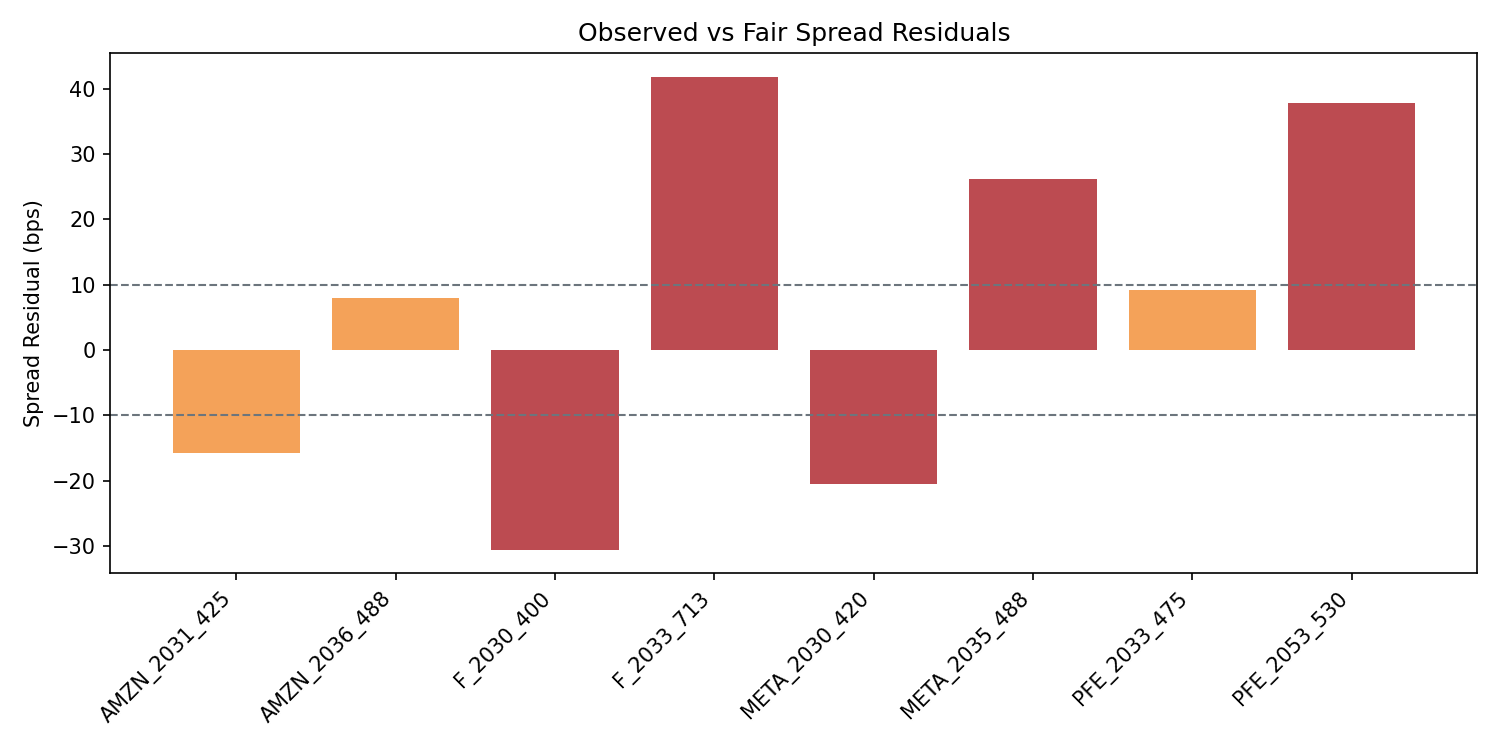

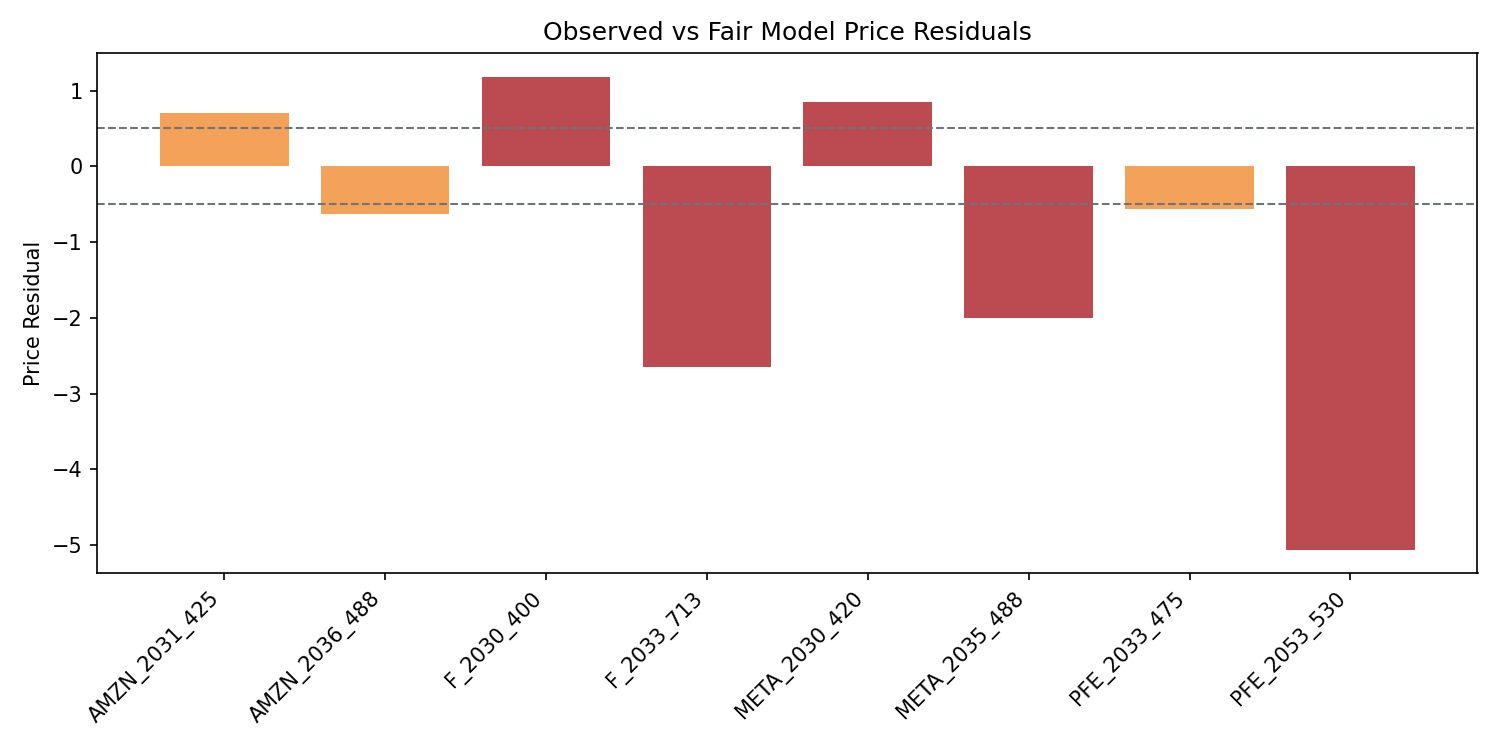

In [5]:
chart_dir = PROJECT_ROOT / "outputs" / "charts"
display(Image(filename=str(chart_dir / "spread_residuals.png")))
display(Image(filename=str(chart_dir / "price_residuals.png")))

In the current sample, most flags come from the small public bond universe and the simple comp model. That still makes the output useful as a quick check on which bonds look far from their peers.